In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

In [3]:
df = pd.read_csv('hospital_readmissions_30k.csv')

In [4]:
df[['systolic_bp', 'diastolic_bp']] = df['blood_pressure'].str.split('/', expand=True).astype(float)

In [5]:
binary_cols = ['diabetes', 'hypertension', 'readmitted_30_days']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [6]:
df_processed = pd.get_dummies(
    df.drop(columns=['patient_id', 'blood_pressure']),
    columns=['gender', 'discharge_destination'],
    drop_first=True
)

In [7]:
X = df_processed.drop(columns=['readmitted_30_days'])
y = df_processed['readmitted_30_days']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [11]:
model = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [12]:
y_pred_probs = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)
auc_score = roc_auc_score(y_test, y_pred_probs)

print(f"Dataset Size: {len(df):,} records")
print(f"ROC-AUC Score: {auc_score:.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Dataset Size: 30,000 records
ROC-AUC Score: 0.5634

Confusion Matrix:
[[3723 1542]
 [ 439  296]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      5265
           1       0.16      0.40      0.23       735

    accuracy                           0.67      6000
   macro avg       0.53      0.55      0.51      6000
weighted avg       0.80      0.67      0.72      6000



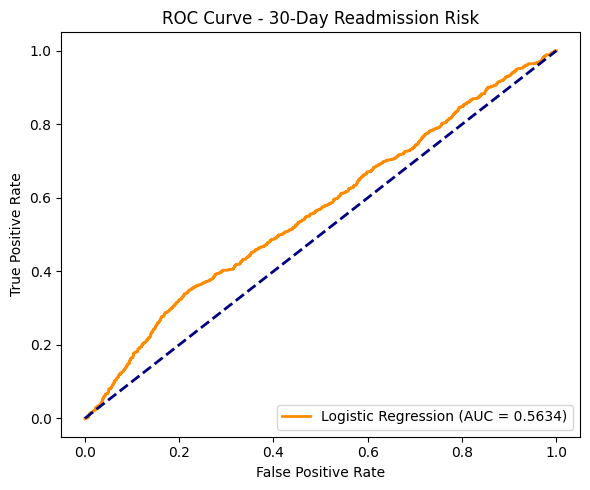

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 30-Day Readmission Risk')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('readmission_roc_curve.png')
plt.savefig('readmission_roc_curve.png')
plt.show()  # <--- Add this to render the plot on screen
plt.close()